In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import cftime
import cf_xarray
import warnings
warnings.filterwarnings("ignore")

In [2]:
import ecubevis as ecv

Task1: Load GFDL_SSP585 (ds_S1) & GFDL_Historical (ds_H) (100km) regridded as Model Future and Model History & ERA5 Upscaled (100km) (dsE) as reference # We keep the reference time period (1985-2014) for correcting bias. We created a folder for storing reference data, biased data and finally bias corredted data using this path "/glade/work/mbadhan/Bias_Correction_100km_GFDL_using_ERA5_1985_2014/PRCP/" (for future work)

# Load Data

In [14]:
#load GFDL_100km Historical Data (ds_H) & GFDL_100km SSP585 (ds_S1) & ERA5 Upscaled (100km) (dsE) as reference # We keep the reference time period same (1985-2014) for correcting bias
ds_H = xr.open_dataset(r'/glade/work/mbadhan/Bias_Correction_100km_GFDL_using_ERA5_1985_2014/PRCP/Pr_GFDL85_15NE_HIST.nc') #CMIP6_Historical(1985-2014)_100km Regridded
ds_S1 = xr.open_dataset(r'/glade/work/mbadhan/Bias_Correction_100km_GFDL_using_ERA5_1985_2014/PRCP/Pr_GFDL70_99NE_SSP585.nc') #CMIP6_SSP585(2070-2099)_100km Regridded
dsE = xr.open_dataset(r'/glade/work/mbadhan/Bias_Correction_100km_GFDL_using_ERA5_1985_2014/PRCP/era5_mm_targrid_noleap.nc') #ERA5_Daily_Precipitation (1985-2014)

In [7]:
ds_H 

<xarray.Dataset>
Dimensions:    (time: 10950, bnds: 2, lon: 15, lat: 10)
Coordinates:
  * time       (time) object 1985-01-01 12:00:00 ... 2014-12-31 12:00:00
  * lon        (lon) float64 -78.62 -77.62 -76.62 ... -66.62 -65.62 -64.62
  * lat        (lat) float64 45.62 44.62 43.62 42.62 ... 39.62 38.62 37.62 36.62
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object ...
    pr         (time, lat, lon) float32 ...
Attributes: (12/48)
    CDI:                    Climate Data Interface version 1.9.9rc1 (https://...
    history:                Tue Aug 08 18:03:57 2023: cdo remapnn,100km_res_E...
    source:                 GFDL-ESM4 (2018):\natmos: GFDL-AM4.1 (Cubed-spher...
    institution:            National Oceanic and Atmospheric Administration, ...
    Conventions:            CF-1.7 CMIP-6.0 UGRID-1.0
    external_variables:     areacella
    ...                     ...
    tracking_id:            hdl:21.14100/6b7547fa-5d2e-4620-b155-da8a397660f6
    variable_id:            pr
    variant_info:           N/A
    references:             see further_info_url attribute
    variant_label:          r1i1p1f1
    CDO:                    Climate Data Operators version 1.9.9rc1 (https://...

In [8]:
ds_S1

<xarray.Dataset>
Dimensions:    (time: 10950, bnds: 2, lon: 15, lat: 10)
Coordinates:
  * time       (time) object 2070-01-01 12:00:00 ... 2099-12-31 12:00:00
  * lon        (lon) float64 -78.62 -77.62 -76.62 ... -66.62 -65.62 -64.62
  * lat        (lat) float64 45.62 44.62 43.62 42.62 ... 39.62 38.62 37.62 36.62
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object ...
    pr         (time, lat, lon) float32 ...
Attributes: (12/48)
    CDI:                    Climate Data Interface version 1.9.9rc1 (https://...
    history:                Tue Aug 08 18:24:55 2023: cdo remapnn,100km_res_E...
    source:                 GFDL-ESM4 (2018):\natmos: GFDL-AM4.1 (Cubed-spher...
    institution:            National Oceanic and Atmospheric Administration, ...
    Conventions:            CF-1.7 CMIP-6.0 UGRID-1.0
    external_variables:     areacella
    ...                     ...
    tracking_id:            hdl:21.14100/098838f0-9fa5-45f9-8409-0a287dd5d541
    variable_id:            pr
    variant_info:           N/A
    references:             see further_info_url attribute
    variant_label:          r1i1p1f1
    CDO:                    Climate Data Operators version 1.9.9rc1 (https://...

In [9]:
dsE

<xarray.Dataset>
Dimensions:    (time: 10950, bnds: 2, lon: 15, lat: 10)
Coordinates:
  * time       (time) datetime64[ns] 1985-01-01T11:00:00 ... 2014-12-31T11:00:00
  * lon        (lon) float64 -78.62 -77.62 -76.62 ... -66.62 -65.62 -64.62
  * lat        (lat) float64 45.62 44.62 43.62 42.62 ... 39.62 38.62 37.62 36.62
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] ...
    tp         (time, lat, lon) float32 ...
Attributes:
    CDI:          Climate Data Interface version 1.9.9rc1 (https://mpimet.mpg...
    Conventions:  CF-1.6
    history:      Thu Mar 16 12:03:02 2023: cdo remapbil,grid_100km.txt era_m...
    frequency:    day
    CDO:          Climate Data Operators version 1.9.9rc1 (https://mpimet.mpg...

# Define Functions

In [15]:
def interpolation(df1,df2,target_val,start,end):
    #data1(df1) = cmip6 historic
    #data2(df2) = variable to be interpolated (ERA5)
    val = df2[start]+((target_val-df1[start])*(df2[end]-df2[start])/(df1[end]-df1[start]))      #this is the function for interpolation
    

    return val

In [16]:
def manipulate(data_scaled, df, current_data_var, hist_data_var,cdf):
    
    interpolated_vals = []
    #cdf_val = []
    
    for i in range(len(data_scaled)):
        
        #find the index of closest value 
        start_ind = 0
        end_ind = 0
        
        index = np.abs(df[hist_data_var].values-data_scaled[i]).argmin()
        sign = (df[hist_data_var][index]-data_scaled[i])  #check 0,-  or + val
        
        
        
        try:
            if data_scaled[i] <= df[hist_data_var].max():

                if data_scaled[i] < df[hist_data_var].min():

                    start_ind = len(df)-1
                    end_ind = len(df[df[hist_data_var] > df[hist_data_var][index]])-1
                    
                    interpolated_era5 = interpolation(df[hist_data_var],df[current_data_var],data_scaled[i],start_ind,end_ind)
                    interpolated_vals.append(interpolated_era5)

                #check the indices greater and smaller than the picked number
                elif sign == 0:      # ''df[hist_data_var][index]'' is basically a value at [hist_data_var]=column of a dataframe,[index]=row of a dataframe position
                    #no interpolation needed
                    interpolated_vals.append(df[current_data_var][index])
                            #cdf_val.append(df[cdf][index])


                elif sign > 0:    #Here, [hist_data_var]=column of a dataframe,[index]=row of a dataframe
                    
                    end_ind = index
                    start_ind = len(df) - len(df[df[hist_data_var] < df[hist_data_var][index]])
                    interpolated_era5 = interpolation(df[hist_data_var],df[current_data_var],data_scaled[i],start_ind,end_ind)
                    interpolated_vals.append(interpolated_era5)


                else:

                    start_ind = index
                    end_ind = len(df[df[hist_data_var] > df[hist_data_var][index]])-1
                 
    #                         #interpolated_cdf = interpolation(df[hist_data_var],df[cdf],data_scaled[i],start_ind,end_ind)
                    interpolated_era5 = interpolation(df[hist_data_var],df[current_data_var],data_scaled[i],start_ind,end_ind)
                    interpolated_vals.append(interpolated_era5)
    #                         #cdf_val.append(interpolated_cdf)


            else:
                end_ind = 0
                start_ind = len(df) - len(df[df[hist_data_var] < df[hist_data_var][index]])
                
    #               interpolated_cdf = interpolation(df[hist_data_var],df[cdf],data_scaled[i],start_ind,end_ind)
    #               interpolated_era5 = interpolation(df[cdf],df[current_data_var],interpolated_cdf,start_ind,end_ind)
    #               interpolated_vals.append(interpolated_era5)
    #               cdf_val.append(interpolated_cdf)
                    #interpolated_vals.append(df[current_data_var].max())
                    #cdf_val.append(1)
                    #extrapolate
                interpolated_era5 = interpolation(df[hist_data_var],df[current_data_var],data_scaled[i],start_ind,end_ind)
                interpolated_vals.append(interpolated_era5) 
        
        except:
            print(i,": ", data_scaled[i], df[hist_data_var][index])
            
        #print(data_scaled[i], start_ind,",",end_ind)
            
    return interpolated_vals  #cdf_val

# Create Ordered Dataframe, Monthly Scale Factor Calculations for Everygrid

In [17]:
#Create dataframe with ERA, CMIP6 and future data
#We will order the ERA and CMIP6, future data left as it is
#data1 = ERA netcdf
#data2 = CMIP6 netcdf
#future_data = SSP
def create_df_ordered(data1,data1_var,data2,data2_var,future_data, future_data_var,lat_ind,lon_ind,month):
    
    #create_df(x_array,var,month,lat_ind,lon_ind):

    era_grouped = data1.isel(time = data1.groupby("time.month").groups[month])[data1_var][:,lat_ind,lon_ind]
    hist_grouped = data2.isel(time = data2.groupby("time.month").groups[month])[data2_var][:,lat_ind,lon_ind]
    future = future_data.isel(time = future_data.groupby("time.month").groups[month])[future_data_var][:,lat_ind,lon_ind].values
    
    #sort and unsort future data
    future_numpy = np.array(future)
    ind = np.flip(np.argsort(future_numpy))
    future_sorted = future_numpy[ind]
    
    
    grp_index = future_data.groupby("time.month").groups[month]
    
    era = era_grouped.sortby(era_grouped, ascending=False)
    hist = hist_grouped.sortby(hist_grouped, ascending=False)
    
    size = len(era)
    cdf = [i/size for i in range(size,0,-1)]
    
    df = pd.DataFrame({
        "ERA": era,
        "CMIP6": hist,
        "SSP" : future,
        "SSP_sorted": future_sorted,
        "cdf": cdf
    })

#     mean_cmip = df.CMIP6.mean()
#     mean_ssp = df.SSP.mean()
    from numpy import inf
    
    ratio = np.divide(df.SSP_sorted.values,df.CMIP6.values)
    ratio_corrected = np.nan_to_num(ratio,nan=0, posinf=0, neginf=0)
    
    #store ratio
    ratios = np.zeros(len(ratio_corrected))
    ratios[ind] = ratio_corrected
    
    df["ratio"] = ratios
    #values smaller than 0.0001 replaced by zero
    df.loc[df["SSP"] < 0.0002, ["SSP","ratio"]] = 0
    
    df["SSP_Scaled"] = df["SSP"]/df["ratio"]
    df["SSP_Scaled"].replace([np.inf,-np.inf,np.nan],0,inplace=True)
                             
    future_scaled = df["SSP_Scaled"].values
    
    
    #interpolation
    inter_data = manipulate(future_scaled,df,"ERA","CMIP6","cdf")
    

    scaled_data[grp_index,lat_ind,lon_ind] = future_scaled
    data[grp_index,lat_ind,lon_ind] = inter_data   #index for month(First Year Jan 0-30, then Second Year Jan 366-396,...)
    rat[grp_index,lat_ind,lon_ind] = df["ratio"].values
   
    return df

In [18]:
#numpy array for storing ratios
rat = np.zeros([10950,10,15])
data = np.zeros([10950,10,15])
scaled_data = np.zeros([10950,10,15])
for i in range(10):
    for j in range(15):
        for k in range(1,13):
            create_df_ordered(dsE,"tp",ds_H,"pr",ds_S1,"pr",i,j,k)
    print("processed: ",i)

processed:  0
processed:  1
processed:  2
processed:  3
processed:  4
processed:  5
processed:  6
processed:  7
processed:  8
processed:  9


In [19]:
ds_S1["Bias_corrected_pr"] = (['time', 'lat', 'lon'],  data) #save the file as netcdf

In [20]:
ds_S1

<xarray.Dataset>
Dimensions:            (time: 10950, bnds: 2, lon: 15, lat: 10)
Coordinates:
  * time               (time) object 2070-01-01 12:00:00 ... 2099-12-31 12:00:00
  * lon                (lon) float64 -78.62 -77.62 -76.62 ... -65.62 -64.62
  * lat                (lat) float64 45.62 44.62 43.62 ... 38.62 37.62 36.62
Dimensions without coordinates: bnds
Data variables:
    time_bnds          (time, bnds) object ...
    pr                 (time, lat, lon) float32 ...
    Bias_corrected_pr  (time, lat, lon) float64 1.792 1.203 ... 0.8698 1.301
Attributes: (12/48)
    CDI:                    Climate Data Interface version 1.9.9rc1 (https://...
    history:                Tue Aug 08 18:24:55 2023: cdo remapnn,100km_res_E...
    source:                 GFDL-ESM4 (2018):\natmos: GFDL-AM4.1 (Cubed-spher...
    institution:            National Oceanic and Atmospheric Administration, ...
    Conventions:            CF-1.7 CMIP-6.0 UGRID-1.0
    external_variables:     areacella
    ...                     ...
    tracking_id:            hdl:21.14100/098838f0-9fa5-45f9-8409-0a287dd5d541
    variable_id:            pr
    variant_info:           N/A
    references:             see further_info_url attribute
    variant_label:          r1i1p1f1
    CDO:                    Climate Data Operators version 1.9.9rc1 (https://...

In [21]:
ds_S1["Scaled_pr"] = (['time', 'lat', 'lon'], scaled_data)

In [22]:
ds_S1["ratio"] = (['time', 'lat', 'lon'], rat)

In [23]:
ds_S1

<xarray.Dataset>
Dimensions:            (time: 10950, bnds: 2, lon: 15, lat: 10)
Coordinates:
  * time               (time) object 2070-01-01 12:00:00 ... 2099-12-31 12:00:00
  * lon                (lon) float64 -78.62 -77.62 -76.62 ... -65.62 -64.62
  * lat                (lat) float64 45.62 44.62 43.62 ... 38.62 37.62 36.62
Dimensions without coordinates: bnds
Data variables:
    time_bnds          (time, bnds) object ...
    pr                 (time, lat, lon) float32 ...
    Bias_corrected_pr  (time, lat, lon) float64 1.792 1.203 ... 0.8698 1.301
    Scaled_pr          (time, lat, lon) float64 1.425 1.425 ... 0.7956 1.103
    ratio              (time, lat, lon) float64 1.201 1.201 ... 0.646 0.6306
Attributes: (12/48)
    CDI:                    Climate Data Interface version 1.9.9rc1 (https://...
    history:                Tue Aug 08 18:24:55 2023: cdo remapnn,100km_res_E...
    source:                 GFDL-ESM4 (2018):\natmos: GFDL-AM4.1 (Cubed-spher...
    institution:            National Oceanic and Atmospheric Administration, ...
    Conventions:            CF-1.7 CMIP-6.0 UGRID-1.0
    external_variables:     areacella
    ...                     ...
    tracking_id:            hdl:21.14100/098838f0-9fa5-45f9-8409-0a287dd5d541
    variable_id:            pr
    variant_info:           N/A
    references:             see further_info_url attribute
    variant_label:          r1i1p1f1
    CDO:                    Climate Data Operators version 1.9.9rc1 (https://...

# Creating NetCDF

In [24]:
new_filename_1 = r'/glade/work/mbadhan/Bias_Correction_100km_GFDL_using_ERA5_1985_2014/PRCP/GFDL_SSP585/Bias_Corrected/Pr_GFDL_SSP585_100km_Bias_Corrected(0.0002)_2070_2099.nc'
print ('saving to ', new_filename_1)
ds_S1.to_netcdf(path=new_filename_1)
print ('finished saving')

saving to  /glade/work/mbadhan/Bias_Correction_100km_GFDL_using_ERA5_1985_2014/PRCP/GFDL_SSP585/Bias_Corrected/Pr_GFDL_SSP585_100km_Bias_Corrected(0.0002)_2070_2099.nc
finished saving


In [54]:
corrected_ds_S1=xr.open_dataset(r'/glade/work/mbadhan/Bias_Correction_100km_GFDL_using_ERA5_1985_2014/PRCP/GFDL_SSP585/Bias_Corrected/Pr_GFDL_SSP585_100km_Bias_Corrected(0.0002)_2070_2099.nc')

In [55]:
corrected_ds_S1

<xarray.Dataset>
Dimensions:            (time: 10950, bnds: 2, lon: 15, lat: 10)
Coordinates:
  * time               (time) object 2070-01-01 12:00:00 ... 2099-12-31 12:00:00
  * lon                (lon) float64 -78.62 -77.62 -76.62 ... -65.62 -64.62
  * lat                (lat) float64 45.62 44.62 43.62 ... 38.62 37.62 36.62
Dimensions without coordinates: bnds
Data variables:
    time_bnds          (time, bnds) object ...
    pr                 (time, lat, lon) float32 ...
    Bias_corrected_pr  (time, lat, lon) float64 ...
    Scaled_pr          (time, lat, lon) float64 ...
    ratio              (time, lat, lon) float64 ...
Attributes: (12/48)
    CDI:                    Climate Data Interface version 1.9.9rc1 (https://...
    history:                Tue Aug 08 18:24:55 2023: cdo remapnn,100km_res_E...
    source:                 GFDL-ESM4 (2018):\natmos: GFDL-AM4.1 (Cubed-spher...
    institution:            National Oceanic and Atmospheric Administration, ...
    Conventions:            CF-1.7 CMIP-6.0 UGRID-1.0
    external_variables:     areacella
    ...                     ...
    tracking_id:            hdl:21.14100/098838f0-9fa5-45f9-8409-0a287dd5d541
    variable_id:            pr
    variant_info:           N/A
    references:             see further_info_url attribute
    variant_label:          r1i1p1f1
    CDO:                    Climate Data Operators version 1.9.9rc1 (https://...

# Subplot for 12 Months

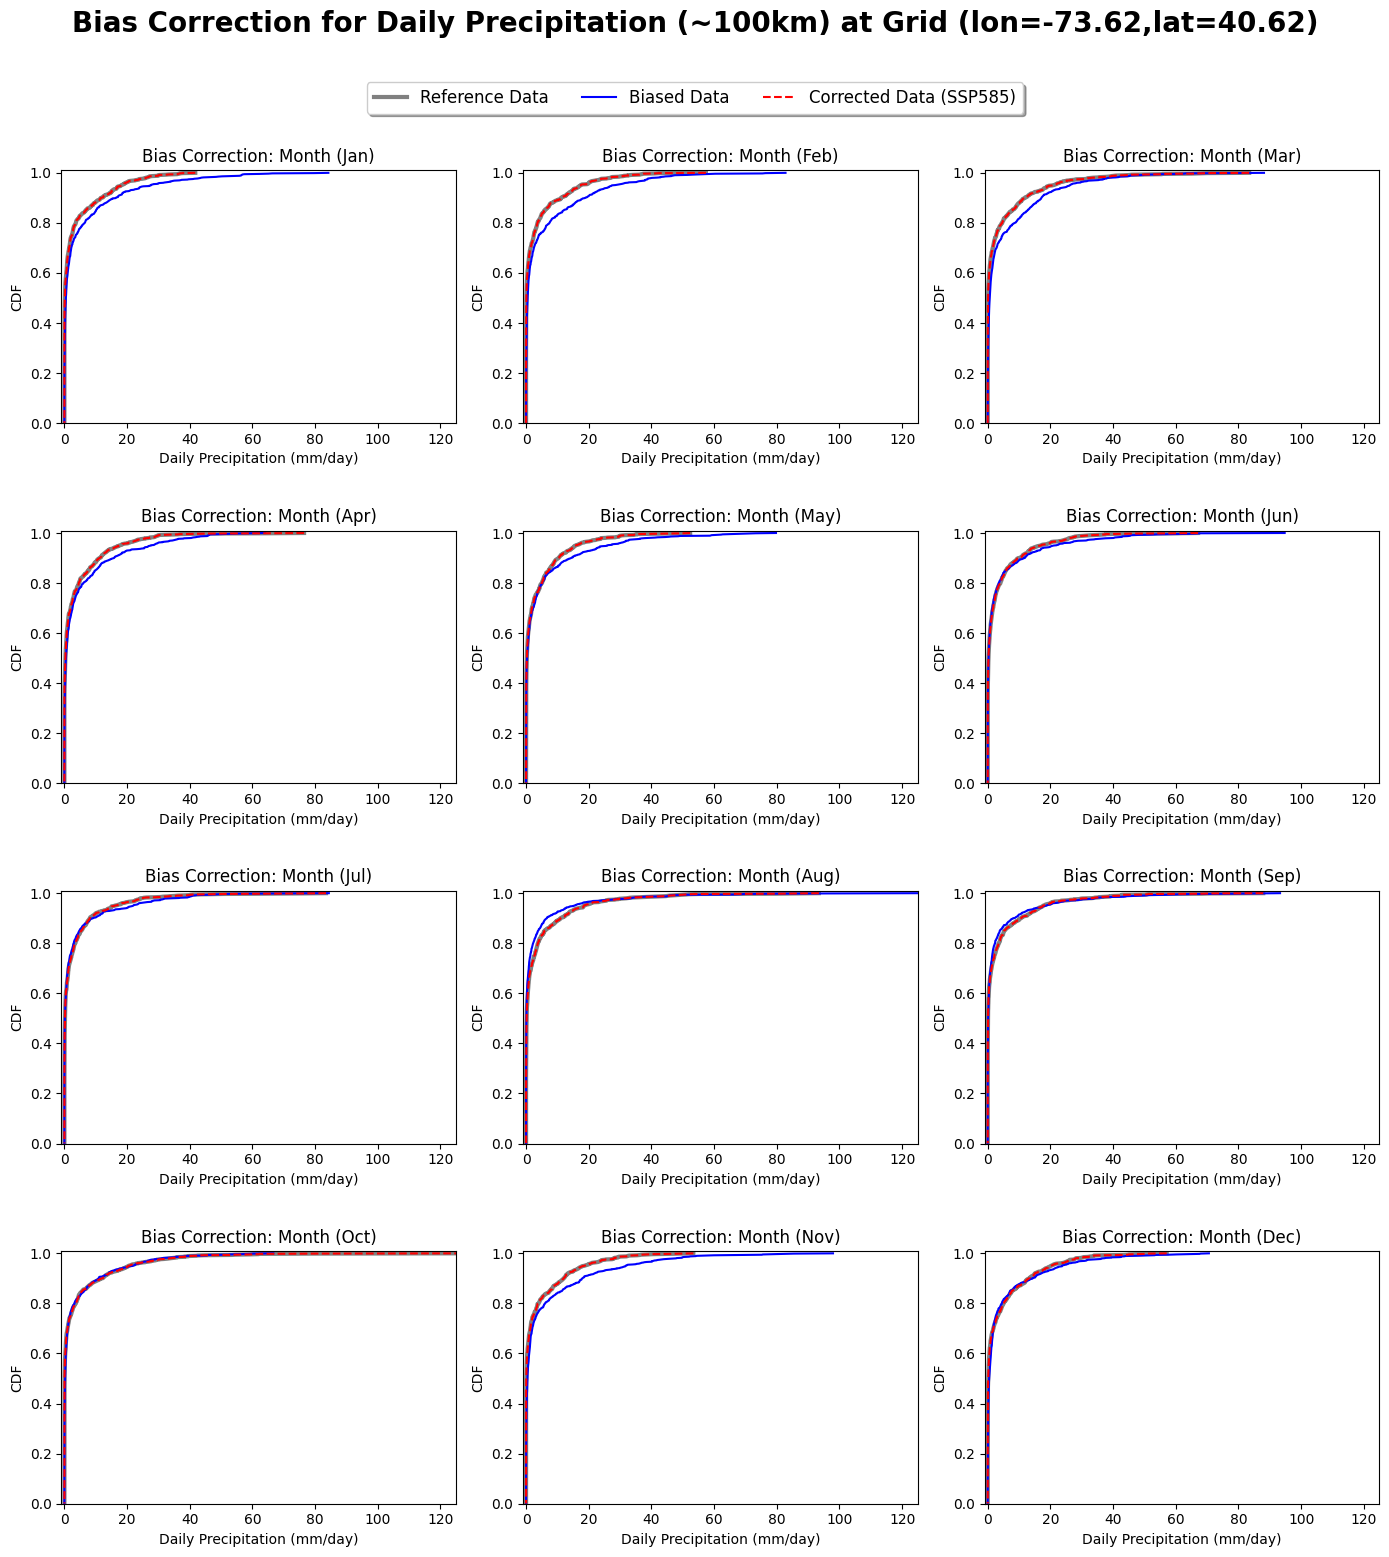

In [62]:
import matplotlib.pyplot as plt
import pandas as pd
import calendar


# Define your functions for creating dataframes here

def create_df(x_array, var, month, lat_ind, lon_ind):
    groups = x_array.groupby("time.month").groups
    filtered = x_array.isel(time=groups[month])
    data = filtered[var][:,lat_ind,lon_ind]
    time = filtered.time

    
    df = pd.DataFrame({
        "Date": time,
        "Pr" : data})
    
    return df

def create_df_plot(data1, data1_var, data2, data2_var, data3, data3_var1, data3_var2, data3_var3, col1, col2, col3, col4, col5, col6, lat_ind, lon_ind, month):
    era = create_df(data1,data1_var,month,lat_ind,lon_ind)
    hist = create_df(data2,data2_var,month,lat_ind,lon_ind)
    s1 = create_df(data3,data3_var1,month,lat_ind,lon_ind)
    s1_Scaled = create_df(data3,data3_var2,month,lat_ind,lon_ind)
    s1_CR= create_df(data3,data3_var3,month,lat_ind,lon_ind)
    
    
    dt1 = era.sort_values("Pr", ascending = False).Pr.values
    dt2 = hist.sort_values("Pr", ascending = False).Pr.values
    dt3 = s1.sort_values("Pr", ascending = False).Pr.values
    dt4 = s1_Scaled.sort_values("Pr", ascending = False).Pr.values
    dt5 = s1_CR.sort_values("Pr", ascending = False).Pr.values
    
    size = len(dt1)
    cdf = [i/size for i in range(size,0,-1)]
    
    df = pd.DataFrame({
        col1: dt1,
        col2: dt2,
        col3: dt3,
        col4: dt4,
        col5: dt5,
        col6: cdf
    })
    
    return df

# Loop through each month and create subplots
fig, axs = plt.subplots(4, 3, figsize=(14, 16))

# Define a list of month names
month_names = [calendar.month_abbr[i] for i in range(1, 13)]  # Use month_abbr for abbreviated month names (e.g., Jan, Feb)

legend_handles = []  # List to collect legend handles
legend_labels = []   # List to collect legend labels

for month in range(1, 13):
    # Get the data for the current month
    dataset_plt = create_df_plot(dsE,"tp",ds_H, "pr", corrected_ds_S1,"pr", "Scaled_pr","Bias_corrected_pr","ERA5","CMIP6_H","SSP585_Original","SSP585_Scaled","Corrected_SSP585","CDF",5,5,month)
    
    frame_plt = pd.DataFrame({
        "ERA5": dataset_plt.ERA5.values,
        "CMIP6_Hist":  dataset_plt.CMIP6_H.values,
        "SSP_585_Original": dataset_plt.SSP585_Original.values,
        "SSP_585_Scaled": dataset_plt.SSP585_Scaled.values,
        "SSP_585_Corrected": dataset_plt.Corrected_SSP585.values,
        "CDF": dataset_plt.CDF.values
    })

    # Calculate subplot position
    row = (month - 1) // 3
    col = (month - 1) % 3
    
    # Plot on the current subplot
    ax = axs[row, col]
    ref_line,= ax.plot(frame_plt["ERA5"], frame_plt["CDF"], linewidth=3, color='gray', label="Reference Data")
    biased_line,= ax.plot(frame_plt["SSP_585_Original"], frame_plt["CDF"], color='blue', label="Biased Data")
    corrected_line,= ax.plot(frame_plt["SSP_585_Corrected"], frame_plt["CDF"], linestyle='--', color='red', label="Corrected Data (SSP585)")
    ax.set_xlim(-1, 125)  # x-axis limits
    ax.set_ylim(0, 1.01)   # y-axis limits
    ax.set_title(f"Bias Correction: Month ({month_names[month - 1]})")  # Use month
    ax.set_xlabel("Daily Precipitation (mm/day)")
    ax.set_ylabel("CDF")
    #ax.legend()

# Collect legend handles and labels
    if month == 1:  # Only collect legend handles and labels once
        legend_handles.append(ref_line)
        legend_handles.append(biased_line)
        legend_handles.append(corrected_line)
        legend_labels.append("Reference Data")
        legend_labels.append("Biased Data")
        legend_labels.append("Corrected Data (SSP585)")


# Add an overall title to the plot
plt.suptitle(f"Bias Correction for Daily Precipitation (~100km) at Grid (lon={dsE.lon.values[5]:.2f},lat={dsE.lat.values[5]:.2f})", fontsize=20, fontweight='bold',y=1.0)

# Add legend between subplot title and subplot
fig.legend(legend_handles, legend_labels, loc='upper center', bbox_to_anchor=(0.5, 0.96), fontsize='large',fancybox=True, shadow=True, ncol=3)

# Adjust layout and display the plot with increased vertical spacing between subplots
plt.tight_layout(rect=[0, 0.03, 1, 0.95], h_pad=3.0)  # Adjust the layout to leave space for the shared title and legend

# Specify the file path and save the plot
# file_path = r'/glade/work/mbadhan/Plot/Bias_Correction/Pr_Ratio_100km/Bias_Correction_Pr_100km_w_ERA5_2070_2099.png'

# plt.savefig(file_path, dpi=600)

plt.show()


# Plotting

In [38]:
def create_df(x_array,var,month,lat_ind,lon_ind):
    groups = x_array.groupby("time.month").groups
    filtered = x_array.isel(time=groups[month])
    data = filtered[var][:,lat_ind,lon_ind]
    time = filtered.time
    
#    mean = data.mean().values
#    std  = data.std()
    
    #print("mean: ", mean,"standard dev: ",std)
    
    df = pd.DataFrame({
        "Date": time,
        "Min_Temp" : data})
    
    return df

In [39]:
#create dataframe variables organized in descending order
def create_df_plot(data1,data1_var,data2,data2_var,data3,data3_var1,data3_var2,data3_var3,col1,col2,col3,col4,col5,col6,lat_ind,lon_ind,month):
    
    #create_df(x_array,var,month,lat_ind,lon_ind):

    era = create_df(data1,data1_var,month,lat_ind,lon_ind)
    hist = create_df(data2,data2_var,month,lat_ind,lon_ind)
    s1 = create_df(data3,data3_var1,month,lat_ind,lon_ind)
    s1_Scaled = create_df(data3,data3_var2,month,lat_ind,lon_ind)
    s1_CR= create_df(data3,data3_var3,month,lat_ind,lon_ind)
    
    
    dt1 = era.sort_values("Min_Temp", ascending = False).Min_Temp.values
    dt2 = hist.sort_values("Min_Temp", ascending = False).Min_Temp.values
    dt3 = s1.sort_values("Min_Temp", ascending = False).Min_Temp.values
    dt4 = s1_Scaled.sort_values("Min_Temp", ascending = False).Min_Temp.values
    dt5 = s1_CR.sort_values("Min_Temp", ascending = False).Min_Temp.values
    
    size = len(dt1)
    cdf = [i/size for i in range(size,0,-1)]
    
    df = pd.DataFrame({
        col1: dt1,
        col2: dt2,
        col3: dt3,
        col4: dt4,
        col5: dt5,
        col6: cdf
    })
    
    return df

In [50]:
dataset_plt = create_df_plot(dsE,"tp",ds_H, "pr", corrected_ds_S1,"pr", "Scaled_pr","Bias_corrected_pr","ERA5","CMIP6_H","SSP585_Original","SSP585_Scaled","Corrected_SSP585","CDF",5,5,3)

In [41]:
dataset_plt.head(5)

,ERA5,CMIP6_H,SSP585_Original,SSP585_Scaled,Corrected_SSP585,CDF
0,76.477760,79.529861,64.052963,79.529862,76.477761,1.000000
1,64.955170,70.405205,59.636238,70.405204,64.955169,0.998889
2,45.976711,60.285370,54.907402,60.285368,45.976708,0.997778
3,40.809948,57.554008,52.704472,57.554009,40.809950,0.996667
4,36.901997,50.955452,50.057827,50.955451,36.901995,0.995556


In [42]:
dataset_plt.tail(5)

,ERA5,CMIP6_H,SSP585_Original,SSP585_Scaled,Corrected_SSP585,CDF
895,0.0,0.000005,5.305079e-06,0.0,0.0,0.005556
896,0.0,0.000005,1.539339e-06,0.0,0.0,0.004444
897,0.0,0.000004,1.535832e-06,0.0,0.0,0.003333
898,0.0,0.000002,8.882440e-07,0.0,0.0,0.002222
899,0.0,0.000002,4.432848e-09,0.0,0.0,0.001111


In [43]:
import xarray as xr 
# import the matplotlib, which is converted from matplot of MatLab
import matplotlib.pyplot as plt 
import pandas as pd
import glob
import math
import cartopy.crs as ccrs # Python package designed for geospatial data processing in order to produce maps and other geospatial data analyses.
import numpy as np #package with multidimensional array manipulators
# the following section import individual functions from specific packages
from matplotlib import cm # import the cm function
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter #function to add lat/lon labels
from cartopy.util import add_cyclic_point #function to "wrap" the data into a sphere. Aka, the program adds values of 0° longitude next to 360° longitude, and 360° before 0 
from numpy import linspace # function to create evenly spaced numbers over a specified interval.

In [51]:
frame_plt = pd.DataFrame({
    "ERA5": dataset_plt.ERA5.values,
    "CMIP6_Hist":  dataset_plt.CMIP6_H.values,
    "SSP_585_Original": dataset_plt.SSP585_Original.values,
    "SSP_585_Scaled": dataset_plt.SSP585_Scaled.values,
    "SSP_585_Corrected": dataset_plt.Corrected_SSP585.values,
    "CDF": dataset_plt.CDF.values
})

In [52]:
frame_plt.head(5)

,ERA5,CMIP6_Hist,SSP_585_Original,SSP_585_Scaled,SSP_585_Corrected,CDF
0,83.425865,84.946991,88.148338,84.946986,83.425860,1.000000
1,70.064743,73.792053,76.022781,73.792053,70.064743,0.998925
2,66.913391,65.864395,63.227062,65.864395,66.913391,0.997849
3,64.913406,56.712219,62.550777,56.712222,64.913407,0.996774
4,55.808235,49.456299,61.073780,49.456301,55.808237,0.995699


In [46]:
frame_plt.tail(5)

,ERA5,CMIP6_Hist,SSP_585_Original,SSP_585_Scaled,SSP_585_Corrected,CDF
895,0.0,0.000005,5.305079e-06,0.0,0.0,0.005556
896,0.0,0.000005,1.539339e-06,0.0,0.0,0.004444
897,0.0,0.000004,1.535832e-06,0.0,0.0,0.003333
898,0.0,0.000002,8.882440e-07,0.0,0.0,0.002222
899,0.0,0.000002,4.432848e-09,0.0,0.0,0.001111


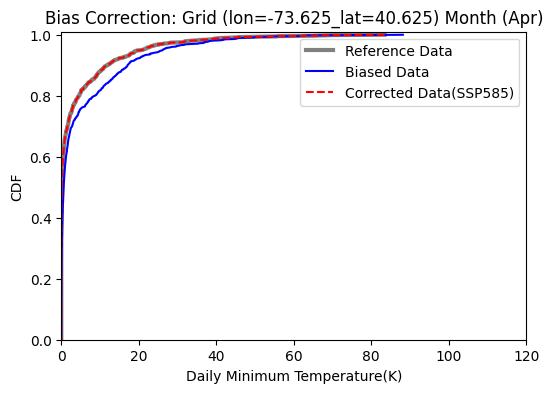

In [53]:
import matplotlib.pyplot as plt 
plt.figure(num=None, figsize=(6, 4),  facecolor='w', edgecolor='k')
        
ax = plt.gca()



check_indexed = frame_plt.set_index('CDF')
plt.plot(check_indexed["ERA5"],check_indexed.index, linewidth=3, color = 'gray',label="Reference Data")
plt.plot(check_indexed["SSP_585_Original"],check_indexed.index, color = 'blue',label="Biased Data")
#plt.plot(check_indexed["CMIP6_Hist"],check_indexed.index, color = 'pink',label="Historical Data")


#check_indexed = check.set_index('inter_cdf')
plt.plot(check_indexed["SSP_585_Corrected"],check_indexed.index,linestyle='--', color = 'red',label="Corrected Data(SSP585)")

plt.xlim(0, 120)  # x-axis limits
plt.ylim(0, 1.01)  # y-axis limits

plt.title("Bias Correction: Grid (lon=-73.625_lat=40.625) Month (Apr)")
plt.xlabel("Daily Minimum Temperature(K)")
plt.ylabel("CDF")
plt.legend()
plt.show()

# Task 2: Bias Correction of Historical Period simply using Quantile Mapping!

In [3]:
#Attention(Here ds_S1 is the Historical GFDL )
#load GFDL_100km (ds_S1) & ERA5 Upscaled (100km) (dsL) as reference # We keep the reference time period same (1985-2014) for correcting bias
ds_S1 = xr.open_dataset(r'/glade/work/mbadhan/Bias_Correction_100km_GFDL_using_ERA5_1985_2014/PRCP/Pr_GFDL85_15NE_HIST.nc') #CMIP6_Historical_GFDL(1985-2014)_100km
dsL = xr.open_dataset(r'/glade/work/mbadhan/Bias_Correction_100km_GFDL_using_ERA5_1985_2014/PRCP/era5_mm_targrid_noleap.nc') #ERA5_Daily_Precipitation(1985-2014)_100km

In [5]:
ds_S1

<xarray.Dataset>
Dimensions:    (time: 10950, bnds: 2, lon: 15, lat: 10)
Coordinates:
  * time       (time) object 1985-01-01 12:00:00 ... 2014-12-31 12:00:00
  * lon        (lon) float64 -78.62 -77.62 -76.62 ... -66.62 -65.62 -64.62
  * lat        (lat) float64 45.62 44.62 43.62 42.62 ... 39.62 38.62 37.62 36.62
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object ...
    pr         (time, lat, lon) float32 ...
Attributes: (12/48)
    CDI:                    Climate Data Interface version 1.9.9rc1 (https://...
    history:                Tue Aug 08 18:03:57 2023: cdo remapnn,100km_res_E...
    source:                 GFDL-ESM4 (2018):\natmos: GFDL-AM4.1 (Cubed-spher...
    institution:            National Oceanic and Atmospheric Administration, ...
    Conventions:            CF-1.7 CMIP-6.0 UGRID-1.0
    external_variables:     areacella
    ...                     ...
    tracking_id:            hdl:21.14100/6b7547fa-5d2e-4620-b155-da8a397660f6
    variable_id:            pr
    variant_info:           N/A
    references:             see further_info_url attribute
    variant_label:          r1i1p1f1
    CDO:                    Climate Data Operators version 1.9.9rc1 (https://...

In [6]:
dsL

<xarray.Dataset>
Dimensions:    (time: 10950, bnds: 2, lon: 15, lat: 10)
Coordinates:
  * time       (time) datetime64[ns] 1985-01-01T11:00:00 ... 2014-12-31T11:00:00
  * lon        (lon) float64 -78.62 -77.62 -76.62 ... -66.62 -65.62 -64.62
  * lat        (lat) float64 45.62 44.62 43.62 42.62 ... 39.62 38.62 37.62 36.62
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] ...
    tp         (time, lat, lon) float32 ...
Attributes:
    CDI:          Climate Data Interface version 1.9.9rc1 (https://mpimet.mpg...
    Conventions:  CF-1.6
    history:      Thu Mar 16 12:03:02 2023: cdo remapbil,grid_100km.txt era_m...
    frequency:    day
    CDO:          Climate Data Operators version 1.9.9rc1 (https://mpimet.mpg...

# Define Functions

In [4]:
def get_val(df):

    val = np.zeros(len(df.Livneh))
    for i in range(len(df.Livneh)):
        index = np.abs(df["GFDL_sorted"].values-df.loc[i,"GFDL"]).argmin()
        val[i] = df.Livneh[index]
        
    return val

# Create Ordered Dataframe for Everygrid

In [7]:
#create dataframe with ERA5 Reference Data, CMIP6 100km (1985-2014)
#we will order the ERA5 and CMIP6
#data1 = ERA5 netcdf/Livneh(when 25km) # We didn't change the name because we wrote the code first for livneh(25km)
#data2 = CMIP6 netcdf
def create_df_ordered_new(data1,data1_var,data2,data2_var,lat_ind,lon_ind,month):
    
    #create_df(x_array,var,month,lat_ind,lon_ind):

    livneh_grouped = data1.isel(time = data1.groupby("time.month").groups[month])[data1_var][:,lat_ind,lon_ind]
    gfdl_grouped = data2.isel(time = data2.groupby("time.month").groups[month])[data2_var][:,lat_ind,lon_ind]
    #gfdl = data2.isel(time = data2.groupby("time.month").groups[month])[data2_var][:,lat_ind,lon_ind].values
    
    #sort and unsort future data
    #gfdl_numpy = np.array(gfdl)
    #ind = np.flip(np.argsort(gfdl_numpy))
    #gfdl_sorted = gfdl_numpy[ind]
    
    
    grp_index = data2.groupby("time.month").groups[month]
    
    livneh_sorted = livneh_grouped.sortby(livneh_grouped, ascending=False)
    gfdl_sorted = gfdl_grouped.sortby(gfdl_grouped, ascending=False)
    
    size = len(livneh_sorted)
    cdf = [i/size for i in range(size,0,-1)]
    
    df = pd.DataFrame({
        "Livneh": livneh_sorted,
        "GFDL" : gfdl_grouped,
        "GFDL_sorted": gfdl_sorted,
        "cdf": cdf
    })

#     mean_cmip = df.CMIP6.mean()
#     mean_ssp = df.SSP.mean()

    #future_scaled = df["SSP_Scaled"].values
    
    #interpolation
    #inter_data = manipulate(future_scaled,df,"ERA","CMIP6","cdf")
    
    #get the corresponding row index
    data = get_val(df)

    final_data[grp_index,lat_ind,lon_ind] = data
    
    #data[grp_index,lat_ind,lon_ind] = inter_data   #index for month(First Year Jan 0-30, then Second Year Jan 366-396,...)
    #rat[grp_index,lat_ind,lon_ind] = df["ratio"].values
   
    return df

In [8]:
#numpy array for storing ratios
#rat = np.zeros([10950,10,15])
#data = np.zeros([10950,10,15])
final_data = np.zeros([10950,10,15])
for i in range(10):
    for j in range(15):
        for k in range(1,13):
            create_df_ordered_new(dsL,"tp",ds_S1,"pr",i,j,k)
    print("processed: ",i)

processed:  0
processed:  1
processed:  2
processed:  3
processed:  4
processed:  5
processed:  6
processed:  7
processed:  8
processed:  9


In [9]:
test_liv = dsL.isel(time = dsL.groupby("time.month").groups[1])["tp"][:,0,0].values
test_s1 = ds_S1.isel(time = ds_S1.groupby("time.month").groups[1])["pr"][:,0,0].values

In [10]:
tL = -np.sort(-test_liv)     #'tL' is the sorted livneh data
tS1 = -np.sort(-test_s1)     # 'tS1' is the sorted GFDL data

In [11]:
test_df = pd.DataFrame({
    "tL" : tL,
    "ts" : tS1,
    "data" : test_s1                    #test_s1 is the unsorted GFDL data
})

In [20]:
test_df.head(80)

,tL,ts,data
0,34.963364,33.319328,0.516361
1,32.672050,30.258554,5.168081
2,27.670532,26.749390,0.031697
3,26.180685,23.858788,3.259978
4,24.953156,22.714758,3.789328
...,...,...,...
75,7.176263,5.408355,1.909138
76,7.167541,5.382550,4.446332
77,7.163742,5.204835,2.307506
78,7.082884,5.193620,0.541826


In [18]:
final_data[:5,0,0]

array([0.55937082, 7.08127117, 0.0097534 , 4.64446592, 5.29639959])

In [21]:
ds_S1["Bias_corrected_pr"] = (['time', 'lat', 'lon'],  final_data) #save the file as netcdf

# Creating NetCDF

In [22]:
new_filename_1 = r'/glade/work/mbadhan/Bias_Correction_100km_GFDL_using_ERA5_1985_2014/PRCP/GFDL_Historical/Bias_Corrected/Pr_GFDL.Historical_100km_Bias_Corrected_1985_2014.nc'
print ('saving to ', new_filename_1)
ds_S1.to_netcdf(path=new_filename_1)
print ('finished saving')

saving to  /glade/work/mbadhan/Bias_Correction_100km_GFDL_using_ERA5_1985_2014/PRCP/GFDL_Historical/Bias_Corrected/Pr_GFDL.Historical_100km_Bias_Corrected_1985_2014.nc
finished saving


In [23]:
corrected_ds_S1=xr.open_dataset(r'/glade/work/mbadhan/Bias_Correction_100km_GFDL_using_ERA5_1985_2014/PRCP/GFDL_Historical/Bias_Corrected/Pr_GFDL.Historical_100km_Bias_Corrected_1985_2014.nc')

In [26]:
corrected_ds_S1

<xarray.Dataset>
Dimensions:            (time: 10950, bnds: 2, lon: 15, lat: 10)
Coordinates:
  * time               (time) object 1985-01-01 12:00:00 ... 2014-12-31 12:00:00
  * lon                (lon) float64 -78.62 -77.62 -76.62 ... -65.62 -64.62
  * lat                (lat) float64 45.62 44.62 43.62 ... 38.62 37.62 36.62
Dimensions without coordinates: bnds
Data variables:
    time_bnds          (time, bnds) object ...
    pr                 (time, lat, lon) float32 ...
    Bias_corrected_pr  (time, lat, lon) float64 ...
Attributes: (12/48)
    CDI:                    Climate Data Interface version 1.9.9rc1 (https://...
    history:                Tue Aug 08 18:03:57 2023: cdo remapnn,100km_res_E...
    source:                 GFDL-ESM4 (2018):\natmos: GFDL-AM4.1 (Cubed-spher...
    institution:            National Oceanic and Atmospheric Administration, ...
    Conventions:            CF-1.7 CMIP-6.0 UGRID-1.0
    external_variables:     areacella
    ...                     ...
    tracking_id:            hdl:21.14100/6b7547fa-5d2e-4620-b155-da8a397660f6
    variable_id:            pr
    variant_info:           N/A
    references:             see further_info_url attribute
    variant_label:          r1i1p1f1
    CDO:                    Climate Data Operators version 1.9.9rc1 (https://...

# Plotting

In [24]:
def create_df(x_array,var,month,lat_ind,lon_ind):
    groups = x_array.groupby("time.month").groups
    filtered = x_array.isel(time=groups[month])
    data = filtered[var][:,lat_ind,lon_ind]
    time = filtered.time
    
#    mean = data.mean().values
#    std  = data.std()
    
    #print("mean: ", mean,"standard dev: ",std)
    
    df = pd.DataFrame({
        "Date": time,
        "Min_Temp" : data})
    
    return df

In [25]:
#create dataframe variables organized in descending order
def create_df_plot(data1,data1_var,data2,data2_var1,data2_var2,col1,col2,col3,col4,lat_ind,lon_ind,month):
    
    #create_df(x_array,var,month,lat_ind,lon_ind):

    livneh = create_df(data1,data1_var,month,lat_ind,lon_ind)
    s1 = create_df(data2,data2_var1,month,lat_ind,lon_ind)
    s1_CR= create_df(data2,data2_var2,month,lat_ind,lon_ind)
    
    
    dt1 = livneh.sort_values("Min_Temp", ascending = False).Min_Temp.values
    dt2 = s1.sort_values("Min_Temp", ascending = False).Min_Temp.values
    dt3 = s1_CR.sort_values("Min_Temp", ascending = False).Min_Temp.values
    
    size = len(dt1)
    cdf = [i/size for i in range(size,0,-1)]
    
    df = pd.DataFrame({
        col1: dt1,
        col2: dt2,
        col3: dt3,
        col4: cdf
    })
    
    return df

In [27]:
dataset_plt = create_df_plot(dsL,"tp",corrected_ds_S1,"pr", "Bias_corrected_pr", "ERA5","Historical_GFDL_100km","Corrected_Historical_GFDL_100km","CDF",5,5,4)

In [28]:
import xarray as xr 
# import the matplotlib, which is converted from matplot of MatLab
import matplotlib.pyplot as plt 
import pandas as pd
import glob
import math
import cartopy.crs as ccrs # Python package designed for geospatial data processing in order to produce maps and other geospatial data analyses.
import numpy as np #package with multidimensional array manipulators
# the following section import individual functions from specific packages
from matplotlib import cm # import the cm function
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter #function to add lat/lon labels
from cartopy.util import add_cyclic_point #function to "wrap" the data into a sphere. Aka, the program adds values of 0° longitude next to 360° longitude, and 360° before 0 
from numpy import linspace # function to create evenly spaced numbers over a specified interval.

In [29]:
dataset_plt

,ERA5,Historical_GFDL_100km,Corrected_Historical_GFDL_100km,CDF
0,76.477760,79.529861,76.477760,1.000000
1,64.955170,70.405205,64.955170,0.998889
2,45.976711,60.285370,45.976711,0.997778
3,40.809948,57.554008,40.809948,0.996667
4,36.901997,50.955452,36.901997,0.995556
...,...,...,...,...
895,0.000000,0.000005,0.000000,0.005556
896,0.000000,0.000005,0.000000,0.004444
897,0.000000,0.000004,0.000000,0.003333
898,0.000000,0.000002,0.000000,0.002222


In [31]:
frame_plt = pd.DataFrame({
    "ERA5": dataset_plt.ERA5.values,
    "Historical_Original_100km": dataset_plt.Historical_GFDL_100km.values,
    "Bias-Corrected_Historical_100km": dataset_plt.Corrected_Historical_GFDL_100km.values,
    "CDF": dataset_plt.CDF.values
})

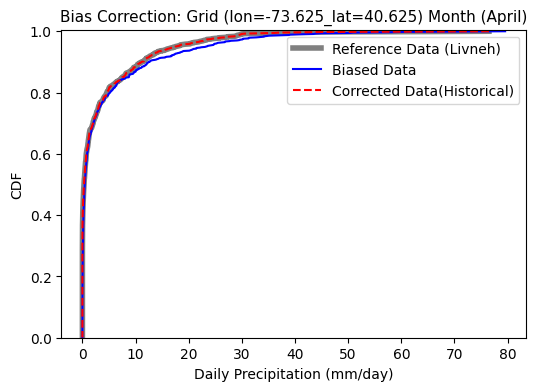

In [32]:
import matplotlib.pyplot as plt 
plt.figure(num=None, figsize=(6, 4),  facecolor='w', edgecolor='k')
        
ax = plt.gca()



check_indexed = frame_plt.set_index('CDF')
plt.plot(check_indexed["ERA5"],check_indexed.index, linewidth=4, color = 'gray',label="Reference Data (Livneh)")
plt.plot(check_indexed["Historical_Original_100km"],check_indexed.index, color = 'blue',label="Biased Data")
#plt.plot(check_indexed["CMIP6_Hist"],check_indexed.index, color = 'pink',label="Historical Data")


#check_indexed = check.set_index('inter_cdf')
plt.plot(check_indexed["Bias-Corrected_Historical_100km"],check_indexed.index,linestyle='--', color = 'red',label="Corrected Data(Historical)")

# plt.xlim(255, 303)  # x-axis limits
plt.ylim(0, 1.005)  # y-axis limits

plt.title("Bias Correction: Grid (lon=-73.625_lat=40.625) Month (April)",fontsize=11, loc="center")
plt.xlabel("Daily Precipitation (mm/day)")
plt.ylabel("CDF")
plt.legend()

# Specify the file path and save the plot
#file_path = r'/glade/work/mbadhan/Plot/Bias_Correction/Tmin/Bias_Correction_Tmin_25km_w_livneh_Apr_2070_2099_UpD.png'

#plt.savefig(file_path, dpi=600)

plt.show()